<a href="https://colab.research.google.com/github/Jhosim-Agudelo/IFT3395-TP2/blob/main/Devoir_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Devoir 2 : Prédiction de propriétés moléculaires par réseaux de neurones

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/mlbook/blob/main/exercises/devoir2_starter.ipynb)

**Session** : Hiver 2026
**Date de remise** : 7 avril 2026
**Travail en équipe** : groupes de 2-3 étudiants
**Évaluation** : cahier Colab (75%), dérivations manuscrites (25%)

## 1. Objectif

Dans ce devoir, vous prédirez la température critique $T_c$ d'une molécule à partir de sa représentation SMILES. Le but est de comparer quatre approches dans un régime de données limitées :

1. caractéristiques fixes + MLP,
2. modèle séquentiel (LSTM) entraîné à partir de zéro,
3. transformeur entraîné à partir de zéro,
4. représentations pré-entraînées avec SMI-TED.

La question centrale est la suivante : sur un jeu de données modeste, est-ce que des modèles plus expressifs suffisent, ou est-ce que des représentations pré-entraînées sont plus utiles ?

## 2. Jeu de données

Vous utiliserez le fichier `chedl_thermo_properties.csv` disponible dans le dépôt [refgen](https://github.com/ddidacus/refgen/tree/main/data). Le fichier contient environ 24 600 molécules avec leur chaîne SMILES et plusieurs propriétés thermodynamiques. La propriété cible pour toutes les équipes est la **température critique** $T_c$ (en kelvins), disponible pour environ 13 100 molécules. Après filtrage des valeurs non manquantes pour $T_c$, vous effectuerez une séparation entraînement/validation 80/20 avec la graine aléatoire fournie dans le cahier de départ.

## 3. Livrables et consignes générales

Vous remettez sur Studium :

1. un **cahier Colab**,
2. un **PDF scanné** contenant les dérivations manuscrites.

Il n'y a pas de rapport écrit.

Le cahier doit s'exécuter du début à la fin sans erreur. Pour **chaque modèle entraîné**, vous devez fournir : les courbes de perte d'entraînement et de validation, la MSE de validation, le $R^2$ de validation, et l'écart entraînement-validation. À trois endroits du devoir, marqués $\square$, vous devez écrire une **prédiction** dans une cellule Markdown *avant* d'exécuter le code correspondant. L'utilisation d'outils d'IA est permise. Vous pouvez utiliser PyTorch et ses modules intégrés (`nn.Linear`, `nn.LSTM`, `nn.TransformerEncoder`, etc.). Il n'est pas demandé de réimplémenter ces composants.

In [ ]:
!pip install -q rdkit torch numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [79]:
# === CONFIGURATION ===
PROPRIETE = "Tc"  # Température critique (K) — même propriété pour toutes les équipes
SEED = 42
MEMBRES = ["Prénom Nom 1", "Prénom Nom 2"]

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

URL = "https://raw.githubusercontent.com/ddidacus/refgen/main/data/chedl_thermo_properties.csv"
df_raw = pd.read_csv(URL)

df = df_raw[df_raw[PROPRIETE].notna() & df_raw["SMILES"].notna()].copy()
df = df[["SMILES", PROPRIETE]].reset_index(drop=True)
df.columns = ["smiles", "target"]

train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)

print(f"Propriété : {PROPRIETE}")
print(f"Entraînement : {len(train_df)}, Validation : {len(val_df)}")
print(f"\nStatistiques :")
print(df["target"].describe())

Propriété : Tc
Entraînement : 10504, Validation : 2627

Statistiques :
count    13131.000000
mean       701.367624
std        728.866756
min          0.000000
25%        564.495000
50%        636.040000
75%        718.860000
max      21482.800000
Name: target, dtype: float64


/var/folders/f8/vv_lr4cj0c34t6hlfbmk6nrr0000gn/T/ipykernel_4613/4132196621.py:7: DtypeWarning: Columns (0,6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(URL)


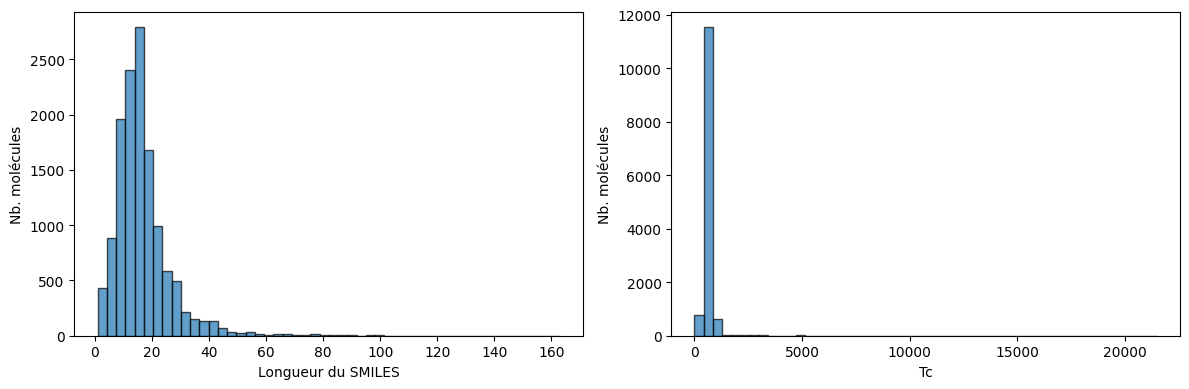

Vocabulaire (60 caractères) : #()+-./123457=@ABCDEFGHIKLMNOPRSTUVWXYZ[\]abcdefghilmnorstuy
Longueur : min=1, max=163, moy=17


In [81]:
smiles_lengths = [len(s) for s in df["smiles"]]
unique_chars = sorted(set("".join(df["smiles"])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(smiles_lengths, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Longueur du SMILES")
axes[0].set_ylabel("Nb. molécules")
axes[1].hist(df["target"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel(PROPRIETE)
axes[1].set_ylabel("Nb. molécules")
plt.tight_layout()
plt.show()

print(f"Vocabulaire ({len(unique_chars)} caractères) : {''.join(unique_chars)}")
print(f"Longueur : min={min(smiles_lengths)}, max={max(smiles_lengths)}, moy={np.mean(smiles_lengths):.0f}")

In [82]:
def plot_learning_curves(train_losses, val_losses, title=""):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="Entraînement")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Époque")
    plt.ylabel("MSE")
    if title:
        plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"Écart train-val : {val_losses[-1] - train_losses[-1]:.4f}")

## Partie 1 — MLP et entraînement (Ch. 7-8)

### 1.1 Caractéristiques fixes et MLP

Chaque chaîne SMILES encode la structure d'une molécule sous forme de texte. Par exemple, `CCO` représente l'éthanol et `c1ccccc1` le benzène. Vous n'avez pas besoin de connaissances en chimie pour ce devoir : il suffit de traiter les SMILES comme des chaînes de caractères. La fonction `smiles_to_features` ci-dessous convertit une chaîne SMILES en un vecteur numérique de longueur fixe. Cette représentation compte la fréquence de chaque caractère du vocabulaire SMILES (par exemple combien de fois `C`, `O`, `(`, `)`, `=` apparaissent), ajoute la longueur totale de la chaîne, et inclut quelques indicatrices binaires. Entraînez un MLP à 2 couches cachées sur ces caractéristiques pour prédire $T_c$.

$\square$ **Prédiction 1** : Avant l'entraînement, écrivez si vous pensez que ce modèle va surapprendre, et justifiez brièvement.

### 1.2 Comparaison d'optimiseurs

Entraînez le **même MLP** avec trois optimiseurs : SGD, SGD avec momentum, et Adam. Gardez la même architecture et les mêmes hyperparamètres, à l'exception de l'optimiseur. Tracez les trois courbes de perte de validation sur un même graphique.

$\square$ **Prédiction 2** : Avant l'expérience, écrivez quel optimiseur convergera le plus vite, et pourquoi.

### 1.3 Régularisation et stabilisation du gradient

Partez d'un MLP profond à 5 couches cachées et comparez les quatre configurations suivantes :

| \# | Configuration |
|---|---|
| 1 | Sigmoid + initialisation par défaut |
| 2 | ReLU + initialisation He |
| 3 | Configuration 2 + BatchNorm |
| 4 | Configuration 3 + Dropout ($p=0.3$) |

Pour chaque configuration, rapportez la MSE de validation finale, la norme moyenne du gradient $\ell_2$ à la première couche cachée (moyennée sur les mini-lots du dernier epoch), et l'écart entraînement-validation.

### Dérivations manuscrites (Partie 1)

Sur papier :

1. Dérivez les règles VJP pour l'opération $\text{matmul}(W, x)$, c'est-à-dire $\partial L / \partial W$ et $\partial L / \partial x$.
2. Dessinez le graphe de calcul complet du MLP à 2 couches, de l'entrée jusqu'à la perte, et annotez les VJP.

In [83]:
# Vocabulaire : tous les caractères uniques présents dans les SMILES du jeu de données
vocab = sorted(set("".join(df["smiles"])))
char_to_idx = {c: i for i, c in enumerate(vocab)}


def smiles_to_features(smiles: str) -> np.ndarray:
    """Convertit une chaîne SMILES en vecteur de caractéristiques de longueur fixe.

    Le vecteur contient :
      - la fréquence de chaque caractère du vocabulaire (taille = len(vocab)),
      - la longueur de la chaîne SMILES.
    """
    counts = np.zeros(len(vocab), dtype=np.float32)
    for c in smiles:
        if c in char_to_idx:
            counts[char_to_idx[c]] += 1
    length = np.array([len(smiles)], dtype=np.float32)
    return np.concatenate([counts, length])


# Construire les matrices de caractéristiques
X_train = np.stack([smiles_to_features(s) for s in train_df["smiles"]])
X_val = np.stack([smiles_to_features(s) for s in val_df["smiles"]])
y_train = train_df["target"].values.astype(np.float32)
y_val = val_df["target"].values.astype(np.float32)

print(f"X_train : {X_train.shape}  (nb. molécules × nb. caractéristiques)")
print(f"X_val   : {X_val.shape}")
print(f"Caractéristiques par molécule : {X_train.shape[1]} ({len(vocab)} fréquences de caractères + 1 longueur)")

X_train : (10504, 61)  (nb. molécules × nb. caractéristiques)
X_val   : (2627, 61)
Caractéristiques par molécule : 61 (60 fréquences de caractères + 1 longueur)


### 1.1
**Prédiction 1** : Ce modele ne risque pas de surraprendre car on a un nombre de parametres relativement faible par rapport au nombre d'exemples d'entraînement (environ 13 000). De plus, les caractéristiques utilisées sont simples.


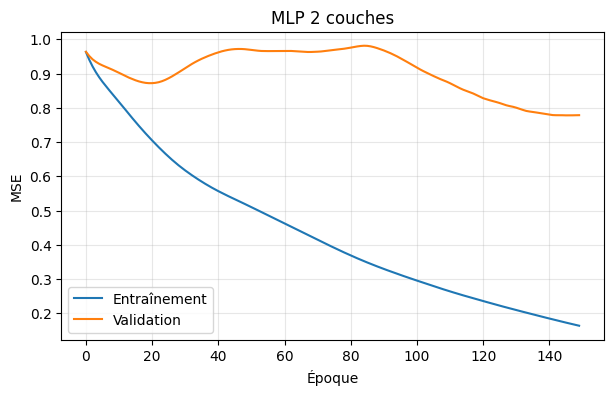

Écart train-val : 0.6150
MSE val : 412041.31 K² | R² val : 0.2356


(412041.3125, 0.23561173677444458)

In [84]:
# Entrainement d'un MLP à 2 couches
from torch import optim
import torch
import torch.nn as nn
from sklearn.metrics import r2_score

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

# Normaliser les features
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_std[X_std == 0] = 1
X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std

# Normaliser la target
y_mean, y_std = y_train.mean(), y_train.std()
y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std

X_train_t = torch.tensor(X_train_norm, dtype=torch.float32)
y_train_t = torch.tensor(y_train_norm, dtype=torch.float32)
X_val_t = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_t = torch.tensor(y_val_norm, dtype=torch.float32)


def print_metrics(model, X_val_t, y_val_t, y_mean, y_std):
    model.eval()
    with torch.no_grad():
        pred_norm = model(X_val_t).squeeze()
    pred = pred_norm.numpy() * y_std + y_mean
    y_true = y_val_t.numpy() * y_std + y_mean
    mse = float(np.mean((pred - y_true)**2))
    r2 = r2_score(y_true, pred)
    print(f"MSE val : {mse:.2f} K² | R² val : {r2:.4f}")
    return mse, r2


def train_mlp(optimizer_name, lr, n_epochs):
    train_losses = []
    val_losses = []

    model = MLP(X_train.shape[1])
    criterion = nn.MSELoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "SGD_momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        y_pred = model(X_train_t).squeeze()

        loss = criterion(y_pred, y_train_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            val_pred = model(X_val_t).squeeze()
            val_loss = criterion(val_pred, y_val_t)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return model, train_losses, val_losses


torch.manual_seed(SEED)
model_mlp, train_l, val_l = train_mlp(optimizer_name="Adam", lr=1e-3, n_epochs=150)
plot_learning_curves(train_l, val_l, "MLP 2 couches")
print_metrics(model_mlp, X_val_t, y_val_t, y_mean, y_std)

# 1.2

**Prédiction 2** : Le modèle Adam est un bon point de départ en général, donc je pense qu'il convergera plus rapidement. SGD et SGD avec momentum pourraient surpasser Adam sur des problèmes de vision mais ce n'est pas le cas ici.

In [85]:
torch.manual_seed(SEED)
model_sgd, sgd_train_loss, sgd_val = train_mlp(optimizer_name="SGD", lr=1e-3, n_epochs=150)
torch.manual_seed(SEED)
model_sgdm, sgd_momentum_train_loss, sgd_momentum_val = train_mlp(optimizer_name="SGD_momentum", lr=1e-3, n_epochs=150)
torch.manual_seed(SEED)
model_adam, adam_train_loss, adam_val = train_mlp(optimizer_name="Adam", lr=1e-3, n_epochs=150)

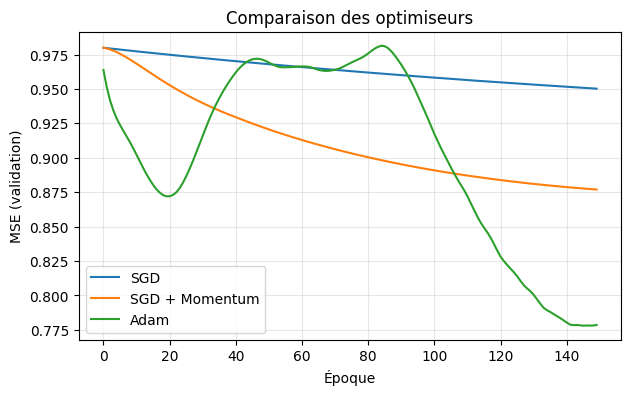

SGD:
MSE val : 502898.59 K² | R² val : 0.0671
SGD + Momentum:
MSE val : 464139.59 K² | R² val : 0.1390
Adam:
MSE val : 412041.31 K² | R² val : 0.2356


In [86]:
plt.figure(figsize=(7, 4))
plt.plot(sgd_val, label="SGD")
plt.plot(sgd_momentum_val, label="SGD + Momentum")
plt.plot(adam_val, label="Adam")
plt.xlabel("Époque")
plt.ylabel("MSE (validation)")
plt.title("Comparaison des optimiseurs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for name, model in [("SGD", model_sgd), ("SGD + Momentum", model_sgdm), ("Adam", model_adam)]:
    print(f"{name}:")
    print_metrics(model, X_val_t, y_val_t, y_mean, y_std)

# 1.3


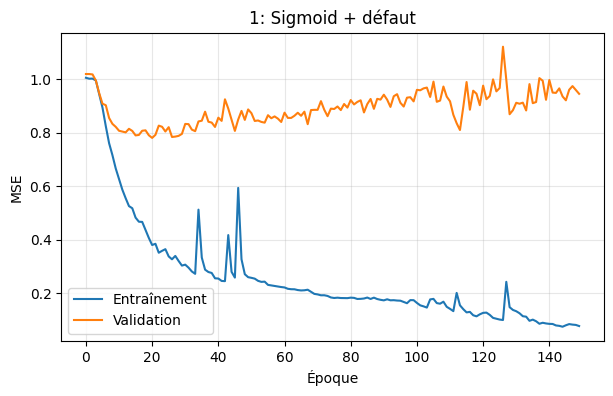

Écart train-val : 0.8663


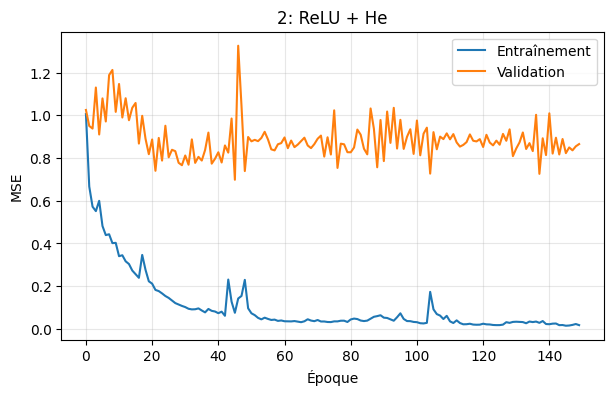

Écart train-val : 0.8486


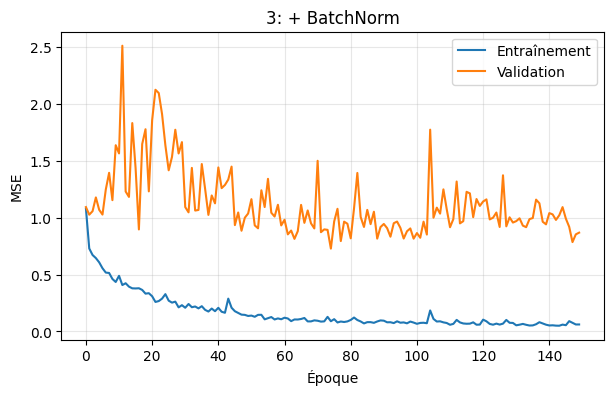

Écart train-val : 0.8067


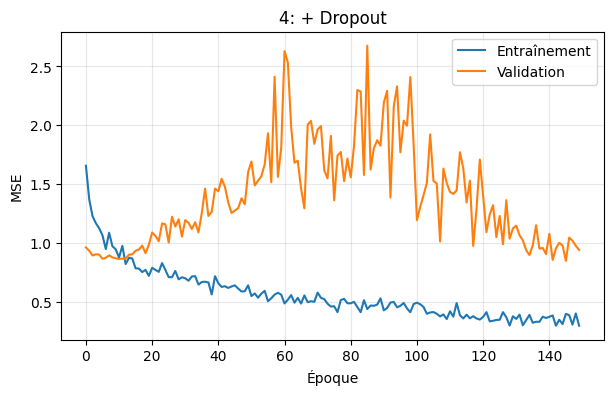

Écart train-val : 0.6424

Config                      MSE val (K²)     R² val    Grad norm   Écart (K²)
---------------------------------------------------------------------------
1: Sigmoid                     499933.12     0.0726     0.901534    458498.47
2: ReLU + He                   458084.12     0.1502     0.339699    449092.31
3: + BatchNorm                 459452.72     0.1477     1.104337    426951.16
4: + Dropout                   499336.25     0.0737     1.695207    339996.09


In [89]:
from torch.utils.data import TensorDataset, DataLoader

input_dim = X_train.shape[1]

class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64,
                 activation="relu", use_batchnorm=False, dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for _ in range(5):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            if activation == "relu":
                layers.append(nn.ReLU())
            else:
                layers.append(nn.Sigmoid())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def init_he(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)


train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)


def train_deep(model, n_epochs=150, lr=1e-3):
    train_losses = []
    val_losses = []
    grad_norms = []

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        epoch_grad_norms = []

        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(X_batch)
            first_layer = model.net[0]
            epoch_grad_norms.append(first_layer.weight.grad.norm().item())

        train_losses.append(epoch_loss / len(train_dataset))
        grad_norms.append(np.mean(epoch_grad_norms))

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze()
            val_loss = criterion(val_pred, y_val_t)
        val_losses.append(val_loss.item())

    return model, train_losses, val_losses, grad_norms


# Config 1: Sigmoid + init par défaut
torch.manual_seed(SEED)
np.random.seed(SEED)
model1 = DeepMLP(input_dim, activation="sigmoid")

# Config 2: ReLU + init He
torch.manual_seed(SEED)
np.random.seed(SEED)
model2 = DeepMLP(input_dim, activation="relu")
model2.init_he()

# Config 3: ReLU + He + BatchNorm
torch.manual_seed(SEED)
np.random.seed(SEED)
model3 = DeepMLP(input_dim, activation="relu", use_batchnorm=True)
model3.init_he()

# Config 4: ReLU + He + BatchNorm + Dropout
torch.manual_seed(SEED)
np.random.seed(SEED)
model4 = DeepMLP(input_dim, activation="relu", use_batchnorm=True, dropout=0.3)
model4.init_he()

torch.manual_seed(SEED)
np.random.seed(SEED)
model1, train_l1, val_l1, grad_norms1 = train_deep(model1)
torch.manual_seed(SEED)
np.random.seed(SEED)
model2, train_l2, val_l2, grad_norms2 = train_deep(model2)
torch.manual_seed(SEED)
np.random.seed(SEED)
model3, train_l3, val_l3, grad_norms3 = train_deep(model3)
torch.manual_seed(SEED)
np.random.seed(SEED)
model4, train_l4, val_l4, grad_norms4 = train_deep(model4)

# Courbes d'apprentissage pour chaque config
configs = [
    ("1: Sigmoid + défaut", train_l1, val_l1),
    ("2: ReLU + He", train_l2, val_l2),
    ("3: + BatchNorm", train_l3, val_l3),
    ("4: + Dropout", train_l4, val_l4),
]
for name, tl, vl in configs:
    plot_learning_curves(tl, vl, name)

# Tableau récapitulatif
print(f"\n{'Config':<25} {'MSE val (K²)':>14} {'R² val':>10} {'Grad norm':>12} {'Écart (K²)':>12}")
print("-" * 75)
for name, mdl, tl, vl, gn in [
    ("1: Sigmoid", model1, train_l1, val_l1, grad_norms1),
    ("2: ReLU + He", model2, train_l2, val_l2, grad_norms2),
    ("3: + BatchNorm", model3, train_l3, val_l3, grad_norms3),
    ("4: + Dropout", model4, train_l4, val_l4, grad_norms4),
]:
    mdl.eval()
    with torch.no_grad():
        pred_norm = mdl(X_val_t).squeeze()
    pred = pred_norm.numpy() * y_std + y_mean
    y_true = y_val_t.numpy() * y_std + y_mean
    mse_val = float(np.mean((pred - y_true)**2))
    r2 = r2_score(y_true, pred)
    ecart = (vl[-1] - tl[-1]) * y_std**2
    print(f"{name:<25} {mse_val:>14.2f} {r2:>10.4f} {np.mean(gn[-1:]):>12.6f} {ecart:>12.2f}")

---
## Partie 2 — Modèles séquentiels et attention

### 🔲 Prédiction 3

Intuitivement, la LSTM devrait mieux performer que le MLP en validation vu qu'il traite les SMILES comme une séquence de chars ordonnés et capture des patterns locaux


In [ ]:
# NORMALISATION
y_mean = y_train.mean()
y_std  = y_train.std()

y_train_norm = (y_train - y_mean) / y_std
y_val_norm   = (y_val   - y_mean) / y_std

print(f"y_mean : {y_mean:.2f} K,  y_std : {y_std:.2f} K")

In [ ]:
# DATASET

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# conversion des smiles en listes nums.
class SMILESDataset(Dataset):
    def __init__(self, smiles_list, targets, char_to_idx):
        self.data = []
        for smi, target in zip(smiles_list, targets):
            indices = torch.tensor(
                [char_to_idx[c] for c in smi if c in char_to_idx],
                dtype=torch.long
            )
            self.data.append((indices, torch.tensor(target, dtype=torch.float32)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# padding en gardant vrai len de chacun
def collate_fn(batch):
    sequences, targets = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    targets = torch.stack(targets)
    return padded, lengths, targets


train_dataset = SMILESDataset(train_df["smiles"].tolist(), y_train_norm, char_to_idx)
val_dataset   = SMILESDataset(val_df["smiles"].tolist(),   y_val_norm,   char_to_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Batches entraînement : {len(train_loader)}")
print(f"Batches validation   : {len(val_loader)}")

In [ ]:

# MODELE LSTM

import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=1, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        out = self.dropout(h_n[-1])
        return self.fc(out).squeeze(1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(vocab_size=len(vocab), embed_dim=64, hidden_dim=128, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()

print(f"Nb. de param: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# ENTRAINEMENT

import torch.nn as nn

EPOCHS = 100
best_val_loss = float("inf")
best_model_state = None
patience, patience_counter = 30, 0
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for x_batch, lengths, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch, lengths)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(y_batch)
    train_losses.append(epoch_loss / len(train_dataset))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, lengths, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch, lengths)
            val_loss += criterion(preds, y_batch).item() * len(y_batch)
    val_losses.append(val_loss / len(val_dataset))

    # verif pour le early stopping apres 30 epochs sans amelioration
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping à l'epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} — Train: {train_losses[-1]:.3f} | Val: {val_losses[-1]:.3f}")

model.load_state_dict(best_model_state)
print(f"\nMeilleur Val MSE : {best_val_loss:.3f}")

In [ ]:
from sklearn.metrics import r2_score

# PREDICTIONS FINALES
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for x_batch, lengths, y_batch in val_loader:
        x_batch = x_batch.to(device)
        preds = model(x_batch, lengths)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

# denormalise
all_preds_denorm   = np.array(all_preds)   * y_std + y_mean
all_targets_denorm = np.array(all_targets) * y_std + y_mean

plot_learning_curves(train_losses, val_losses)

print(f"MSE validation (K²) : {np.mean((all_preds_denorm - all_targets_denorm)**2):.2f}")
print(f"R² validation       : {r2_score(all_targets_denorm, all_preds_denorm):.4f}")

## 2.3 TRANSFORMEUR

In [ ]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [ ]:
# MODELE

class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, lengths):
        batch_size, max_len = x.size()
        mask = torch.arange(max_len, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1).to(x.device)

        emb = self.embedding(x)
        emb = self.pos_encoding(emb)

        out = self.transformer(emb, src_key_padding_mask=mask)

        mask_float = (~mask).unsqueeze(-1).float()
        out = (out * mask_float).sum(dim=1) / mask_float.sum(dim=1)

        return self.fc(out).squeeze(1)


torch.manual_seed(SEED)
model_tr = TransformerModel(
    vocab_size=len(vocab),
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.1
).to(device)
optimizer_tr = torch.optim.Adam(model_tr.parameters(), lr=3e-4, weight_decay=1e-4)

print(f"Nb. paramètres : {sum(p.numel() for p in model_tr.parameters()):,}")

In [ ]:
# ENTRAINEMENT

EPOCHS = 100
best_val_loss_tr = float("inf")
best_model_state_tr = None
patience, patience_counter = 30, 0
train_losses_tr, val_losses_tr = [], []

for epoch in range(EPOCHS):
    model_tr.train()
    epoch_loss = 0
    for x_batch, lengths, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer_tr.zero_grad()
        preds = model_tr(x_batch, lengths)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer_tr.step()
        epoch_loss += loss.item() * len(y_batch)
    train_losses_tr.append(epoch_loss / len(train_dataset))

    model_tr.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, lengths, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model_tr(x_batch, lengths)
            val_loss += criterion(preds, y_batch).item() * len(y_batch)
    val_losses_tr.append(val_loss / len(val_dataset))

    # verif early stoppping
    if val_losses_tr[-1] < best_val_loss_tr:
        best_val_loss_tr = val_losses_tr[-1]
        best_model_state_tr = model_tr.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping à l'epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} — Train: {train_losses_tr[-1]:.3f} | Val: {val_losses_tr[-1]:.3f}")

model_tr.load_state_dict(best_model_state_tr)
print(f"\nMeilleur Val MSE : {best_val_loss_tr:.3f}")

In [ ]:
# PREDICTIONS FINALES

model_tr.eval()
all_preds_tr, all_targets_tr = [], []

with torch.no_grad():
    for x_batch, lengths, y_batch in val_loader:
        x_batch = x_batch.to(device)
        preds = model_tr(x_batch, lengths)
        all_preds_tr.extend(preds.cpu().numpy())
        all_targets_tr.extend(y_batch.numpy())

all_preds_tr_denorm   = np.array(all_preds_tr)   * y_std + y_mean
all_targets_tr_denorm = np.array(all_targets_tr) * y_std + y_mean

plot_learning_curves(train_losses_tr, val_losses_tr)

print(f"MSE validation (K²) : {np.mean((all_preds_tr_denorm - all_targets_tr_denorm)**2):.2f}")
print(f"R² validation       : {r2_score(all_targets_tr_denorm, all_preds_tr_denorm):.4f}")
print(f"Nb. paramètres      : {sum(p.numel() for p in model_tr.parameters()):,}")

## 2.4 Tableau comparatif

| Modèle | MSE val (K²) | R² val | Nb. paramètres | Écart train-val |
|---|---|---|---|---|
| MLP | 412 041 | 0.2356 | 8 193 | 0.615 |
| LSTM | 281 073 | 0.4786 | 103 297 | 0.497 |
| Transformeur | 308 689 | 0.4273 | 103 297 | 0.4139 |

---
## Partie 3 — Apprentissage par transfert (Ch. 10 + synthèse)

### 3.1 Plongements SMI-TED

Chargez le modèle pré-entraîné [SMI-TED](https://huggingface.co/ibm-research/materials.smi-ted) à partir du code fourni ci-dessous, puis extrayez un plongement de dimension 768 pour chaque molécule. Visualisez ces plongements en 2D en utilisant `sklearn.decomposition.PCA` ou `sklearn.manifold.TSNE`, colorés par la valeur de $T_c$.

### 3.2 Sonde linéaire

Gelez SMI-TED et entraînez uniquement une couche linéaire sur les plongements extraits pour prédire $T_c$.

### 3.3 Courbe d'efficacité en échantillons

Tracez sur un même graphique la MSE de validation en fonction de la taille d'entraînement (10%, 25%, 50%, 100%) pour les quatre modèles : MLP, LSTM, transformeur, SMI-TED + sonde linéaire. Pour cette section, réutilisez la meilleure configuration choisie à 100% des données, gardez un même budget d'époques pour tous les sous-ensembles, et ne faites pas de nouvel ajustement d'hyperparamètres. Cette figure est la **figure centrale** du devoir.

Complétez aussi le tableau final, à 100% des données :

| Modèle | MSE val | $R^2$ val | Nb. paramètres | Écart train-val |
|---|---|---|---|---|
| MLP | | | | |
| LSTM | | | | |
| Transformeur | | | | |
| SMI-TED + sonde linéaire | | | | |

## 4. Évaluation

### Cahier Colab (75%)

| Élément | Points |
|---|---|
| Le cahier s'exécute sans erreur | 5 |
| 1.1 : MLP fonctionnel + courbes d'apprentissage | 10 |
| 1.2 : comparaison des optimiseurs | 5 |
| 1.3 : 4 configurations + tableau de résultats | 10 |
| 2.1 : LSTM fonctionnel + courbes | 10 |
| 2.3 : transformeur fonctionnel + courbes | 10 |
| 2.4 : tableau comparatif rempli | 5 |
| 3.1 : plongements SMI-TED + visualisation 2D | 5 |
| 3.2 : sonde linéaire fonctionnelle + courbes | 5 |
| 3.3 : courbe d'efficacité en échantillons | 5 |
| 3 prédictions présentes en cellules Markdown | 5 |
| **Total** | **75** |

### Dérivations manuscrites (25%)

| Élément | Points |
|---|---|
| VJP de $\text{matmul}(W, x)$ | 8 |
| Graphe de calcul du MLP annoté avec les VJP | 5 |
| Calcul d'attention à la main | 12 |
| **Total** | **25** |

### Chargement de SMI-TED

SMI-TED est un modèle de fondation pré-entraîné sur 91 millions de molécules.

In [88]:
import os, sys, torch

# Cloner le dépôt et installer les dépendances
!git clone --depth 1 https://github.com/IBM/materials.git /tmp/materials 2>/dev/null || true
!pip install -q pytorch-fast-transformers torch-optimizer huggingface_hub

# Télécharger les poids
SMI_TED_DIR = "/tmp/materials/models/smi_ted/inference/smi_ted_light"
if not os.path.exists(os.path.join(SMI_TED_DIR, "smi_ted_light.pt")):
    from huggingface_hub import hf_hub_download
    hf_hub_download(repo_id="ibm-research/materials.smi-ted",
                    filename="smi_ted_light.pt", local_dir=SMI_TED_DIR)

# Charger le modèle
sys.path.insert(0, "/tmp/materials/models/smi_ted/inference")
from load import load_smi_ted

smi_ted = load_smi_ted(folder=SMI_TED_DIR, ckpt_filename="smi_ted_light.pt")
smi_ted.eval()

# Test rapide
with torch.no_grad():
    test_emb = smi_ted.encode(["CCO", "c1ccccc1"], return_torch=True)
print(f"Plongements : {test_emb.shape}")  # (2, 768)


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-69d0863d-2dfdbb2d441f01a734562b57;22a04c1b-fc87-4a68-a842-8a656228b229)

Entry Not Found for url: https://huggingface.co/ibm-research/materials.smi-ted/resolve/main/smi_ted_light.pt.